In [1]:
#pip install --upgrade category_encoders

In [8]:
#Related to datasets
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import category_encoders as ce

#Related to the results of ml algorithms
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix,accuracy_score
from sklearn.preprocessing import normalize
from sklearn import metrics
import seaborn as sns # statistical data visualization
from sklearn.model_selection import train_test_split
from sklearn import tree
import graphviz

#Reagarding the datasets
from sklearn.datasets import load_digits

#Regarding dimensionality reduction
from sklearn.decomposition import PCA

#Regarding the clustering mechanism
from sklearn.cluster import KMeans
from scipy.cluster import hierarchy
from scipy.cluster.hierarchy import dendrogram

#Regarding the classifier algorithms
from sklearn import svm
from sklearn import naive_bayes
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier # Import Decision Tree Classifier
from sklearn import tree
from sklearn.tree import plot_tree

# Import label encoder
from sklearn import preprocessing

# label_encoder object knows
# how to understand word labels.
label_encoder = preprocessing.LabelEncoder()



LINEAR REGRESSION WITH GRADIANT DESCEND

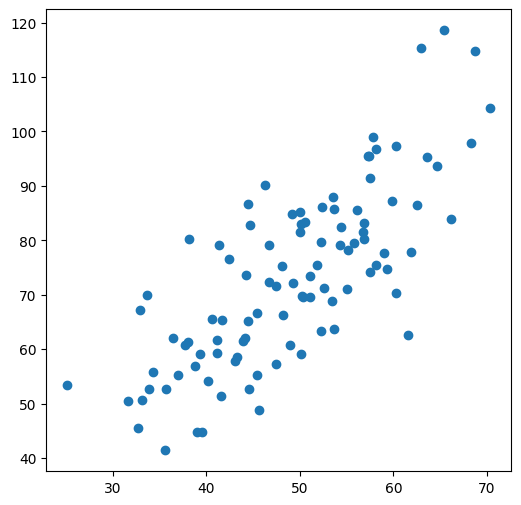

    32.502345269453031  31.70700584656992
0            53.426804          68.777596
1            61.530358          62.562382
2            47.475640          71.546632
3            59.813208          87.230925
4            55.142188          78.211518
..                 ...                ...
94           50.030174          81.536991
95           49.239765          72.111832
96           50.039576          85.232007
97           48.149859          66.224958
98           25.128485          53.454394

[99 rows x 2 columns]


In [12]:
plt.rcParams['figure.figsize'] = (6.0, 6.0)

# Preprocessing Input data
data = pd.read_csv('./public/gd.csv')
X = data.iloc[:, 0]
Y = data.iloc[:, 1]
plt.scatter(X, Y)
plt.show()
print(data)

In [13]:
m = 0
c = 0

L = 0.0001  # The learning Rate
epochs = 1000  # The number of iterations to perform gradient descent

n = float(len(X)) # Number of elements in X

# Performing Gradient Descent
for i in range(epochs):
    Y_pred = m*X + c  # The current predicted value of Y
    D_m = (-2/n) * sum(X * (Y - Y_pred))  # Derivative wrt m
    D_c = (-2/n) * sum(Y - Y_pred)  # Derivative wrt c
    m = m - L * D_m  # Update m
    c = c - L * D_c  # Update c

print (m, c)

1.4796491688889395 0.10148121494753737


In [14]:
regressor1 = LinearRegression()
X = data.iloc[:, 0].values.reshape(-1, 1)
regressor1.fit(X,Y) #actually produces the linear eqn for the data
print(regressor1.intercept_)
print(regressor1.coef_)

9.908606190326537
[1.28735737]


In [19]:
df = pd.read_csv('./public/iris.data')
df['CLASS']= label_encoder.fit_transform(df['CLASS'])
Xdata = df[["SL","SW","PL", "PW"]]
Ydata = df["CLASS"]
X_train, X_test, y_train, y_test = train_test_split(Xdata, Ydata, test_size=0.3, random_state=42, stratify=Ydata)
df

,SL,SW,PL,PW,CLASS
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


CLASSIFICATION ALGORITHMS: SVM

In [20]:
clf = svm.SVC(kernel='linear')
clf.fit(X_train, y_train)
y_pred_svm = clf.predict(X_test)
print("Accuracy (SVM) :",metrics.accuracy_score(y_test, y_pred_svm)*100)

Accuracy (SVM) : 100.0


In [21]:
y_test

107    2
63     1
133    2
56     1
127    2
140    2
53     1
69     1
20     0
141    2
14     0
38     0
108    2
116    2
28     0
148    2
57     1
10     0
23     0
18     0
97     1
7      0
75     1
104    2
138    2
51     1
84     1
93     1
66     1
35     0
134    2
132    2
85     1
49     0
111    2
40     0
42     0
2      0
43     0
77     1
55     1
22     0
106    2
147    2
58     1
Name: CLASS, dtype: int64

In [ ]:
y_pred_svm

array([2, 1, 2, 1, 2, 2, 1, 1, 0, 2, 0, 0, 2, 2, 0, 2, 1, 0, 0, 0, 1, 0,
       1, 2, 2, 1, 1, 1, 1, 0, 2, 2, 1, 0, 2, 0, 0, 0, 0, 1, 1, 0, 2, 2,
       1])

CLASSIFICATION ALGORITHMS: LOGISTIC REGRESSION

In [24]:
logmodel = LogisticRegression()
logmodel.fit(X_train, y_train)
print(logmodel.intercept_)
y_pred_LR= logmodel.predict(X_test)
accuracy = logmodel.score(X_test, y_test)
# or accuracy = accuracy_score(y_test, y_pred_LR)
print(f"Accuracy: {accuracy*100}%")
print('Mean Absolute Error(Logistic Regression):', metrics.mean_absolute_error(y_test, y_pred_LR)*100)

[  9.88227049   2.38677744 -12.26904794]
Accuracy: 93.33333333333333%
Mean Absolute Error(Logistic Regression): 6.666666666666667


CLASSIFICATION ALGORITHM: BERNOULI NAIVE BAYES CLASSIFICATION

---



In [25]:
model = naive_bayes.BernoulliNB()
model.fit(X_train, y_train)
print(model)
expected_y  = y_test
predicted_y = model.predict(X_test)
print(metrics.confusion_matrix(expected_y, predicted_y))
print(classification_report(expected_y, predicted_y))

BernoulliNB()
[[15  0  0]
 [15  0  0]
 [15  0  0]]
              precision    recall  f1-score   support

           0       0.33      1.00      0.50        15
           1       0.00      0.00      0.00        15
           2       0.00      0.00      0.00        15

    accuracy                           0.33        45
   macro avg       0.11      0.33      0.17        45
weighted avg       0.11      0.33      0.17        45



/home/aaron/Documents/ml-dl/venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/aaron/Documents/ml-dl/venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/aaron/Documents/ml-dl/venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

CLASSIFICATION ALGORITHM: KNN CLASSIFICATION


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
KNN_model = KNeighborsClassifier(n_neighbors=15)
KNN_model.fit(X_train, y_train)
KNN_prediction = KNN_model.predict(X_test)
print(accuracy_score(KNN_prediction, y_test))
print(confusion_matrix(KNN_prediction, y_test))
print(classification_report(KNN_prediction, y_test))

0.9555555555555556
[[15  0  0]
 [ 0 14  1]
 [ 0  1 14]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       0.93      0.93      0.93        15
           2       0.93      0.93      0.93        15

    accuracy                           0.96        45
   macro avg       0.96      0.96      0.96        45
weighted avg       0.96      0.96      0.96        45



/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


CLASSIFICATION USING DECISION TREE

In [27]:
model = DecisionTreeClassifier(criterion='entropy',random_state=0)
# Train the model
model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [ ]:
X_train

,SL,SW,PL,PW
98,5.1,2.5,3.0,1.1
68,6.2,2.2,4.5,1.5
19,5.1,3.8,1.5,0.3
143,6.8,3.2,5.9,2.3
99,5.7,2.8,4.1,1.3
...,...,...,...,...
37,4.9,3.1,1.5,0.1
79,5.7,2.6,3.5,1.0
33,5.5,4.2,1.4,0.2
94,5.6,2.7,4.2,1.3



Accuracy = 0.8888888888888888

Feature Importance:
SL  -->  0.028
SW  -->  0.0
PL  -->  0.0511
PW  -->  0.9209


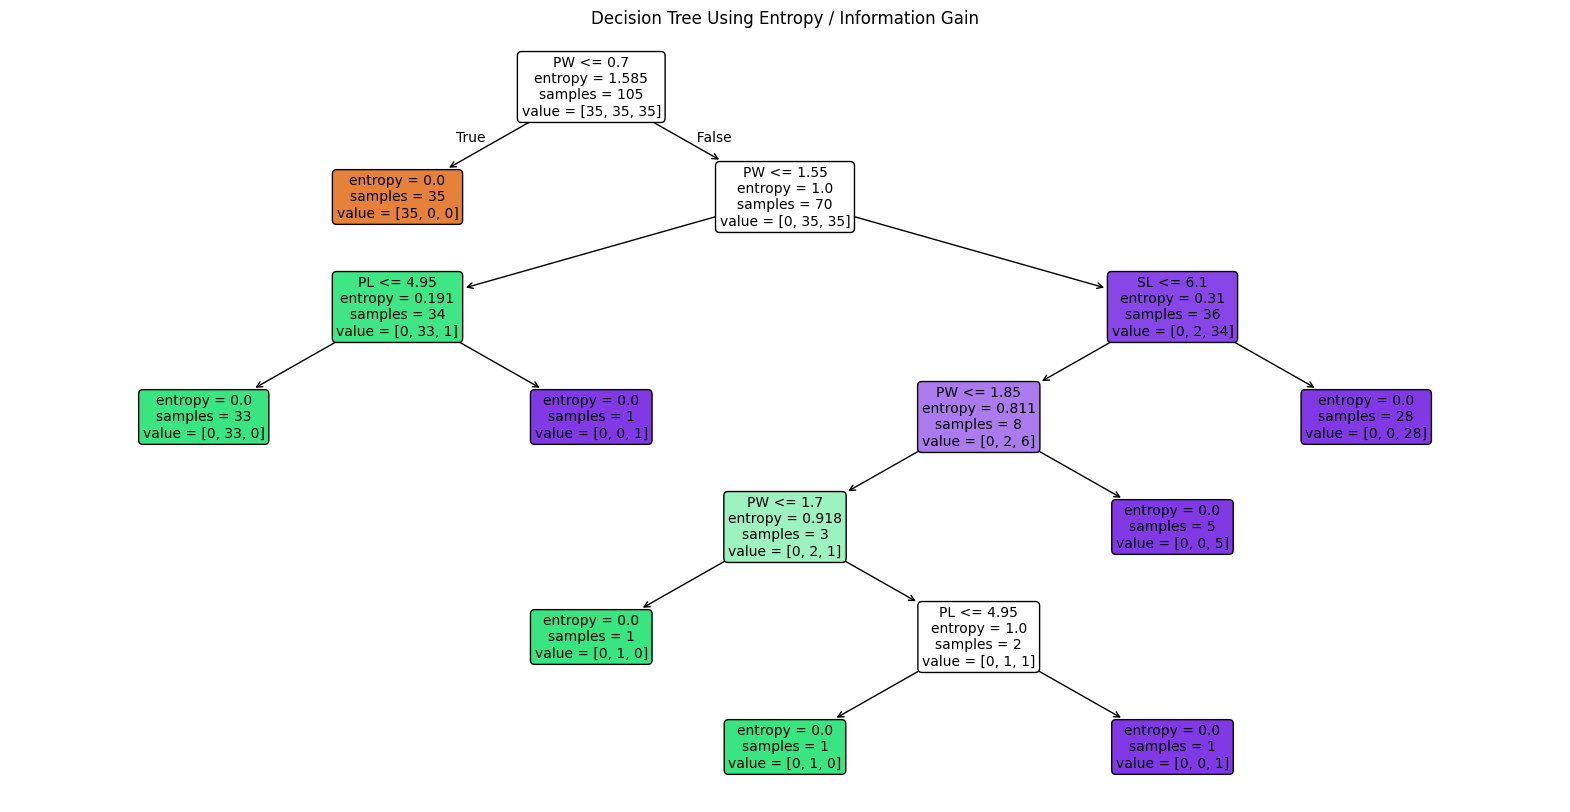

In [28]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("\nAccuracy =", accuracy)
print("\nFeature Importance:")
for feature, importance in zip(X_train.columns,model.feature_importances_):
  print(feature, " --> ", round(importance, 4))

plt.figure(figsize=(20,10))

tree.plot_tree(
    model,
    feature_names=X_train.columns,
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Decision Tree Using Entropy / Information Gain")

plt.show()

CLASSIFICATION RANDOM FOREST

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)



Accuracy = 0.9111

Feature Importance:
SL  -->  0.0992
SW  -->  0.0228
PL  -->  0.4427
PW  -->  0.4353


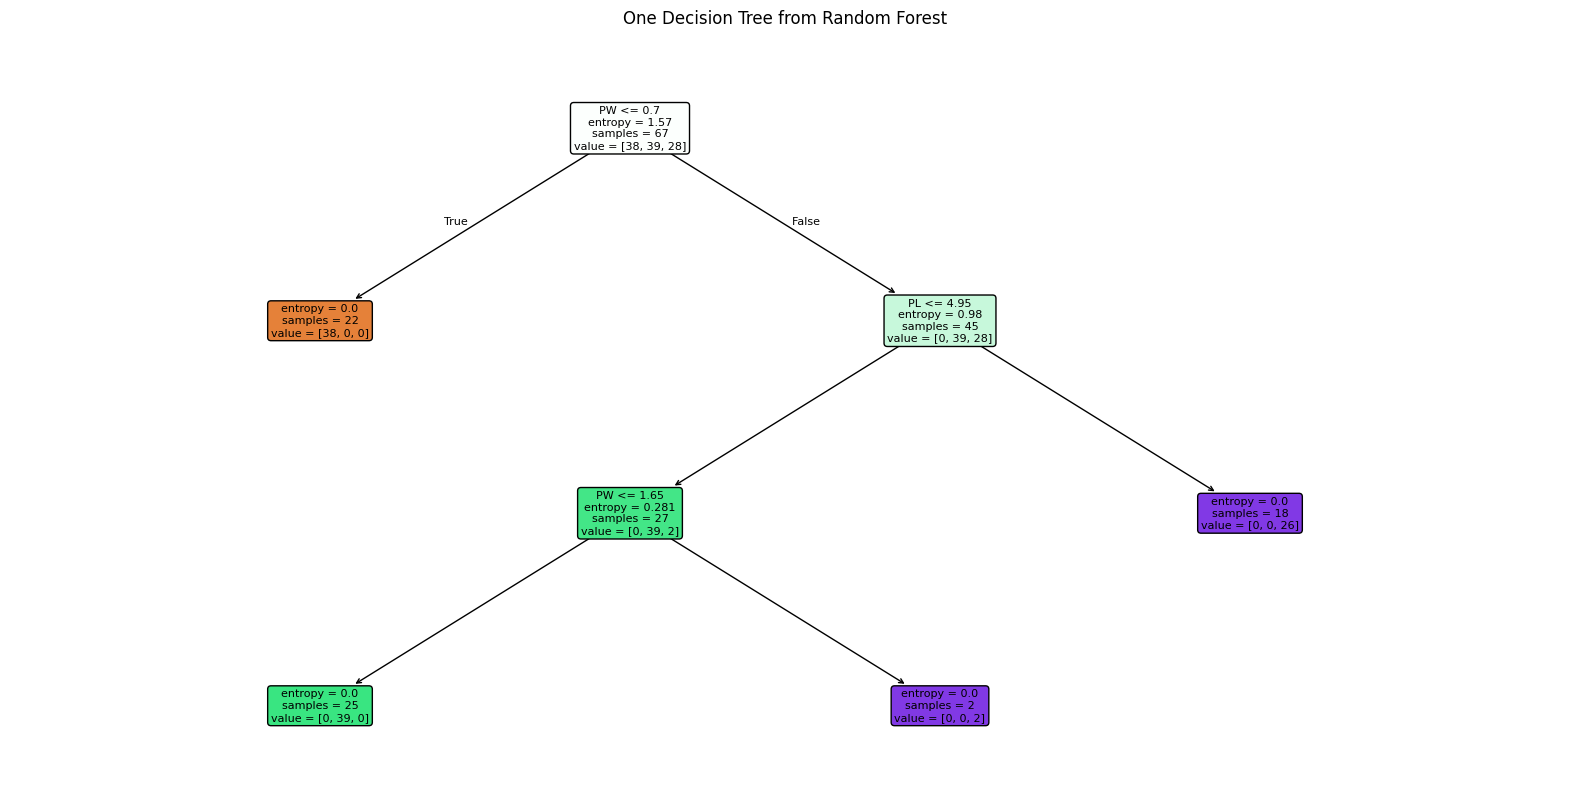

In [ ]:
model = RandomForestClassifier(n_estimators=100,criterion='entropy', random_state=0)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("\nAccuracy =", round(accuracy, 4))
print("\nFeature Importance:")
for feature, importance in zip(X_train.columns,model.feature_importances_):
  print(feature, " --> ", round(importance, 4))
plt.figure(figsize=(20,10))
plot_tree(model.estimators_[0],feature_names=X_train.columns,filled=True,rounded=True,fontsize=8)

plt.title("One Decision Tree from Random Forest")

plt.show()

Dimensionality Reduction : PCA

Original Dataset:

[[ 4 11]
 [ 8  4]
 [13  5]
 [ 7 14]]

Mean of X and Y:
[8.  8.5]

Centered Data:
[[-4.   2.5]
 [ 0.  -4.5]
 [ 5.  -3.5]
 [-1.   5.5]]

Covariance Matrix:
[[ 14. -11.]
 [-11.  23.]]

Eigenvalues:
[ 6.61513568 30.38486432]

Eigenvectors:
[[-0.83025082  0.55738997]
 [-0.55738997 -0.83025082]]

Sorted Eigenvalues:
[30.38486432  6.61513568]

Sorted Eigenvectors:
[[ 0.55738997 -0.83025082]
 [-0.83025082 -0.55738997]]

First Principal Component (PC1):
[ 0.55738997 -0.83025082]

Reduced 1D Data:
[-4.30518692  3.73612869  5.69282771 -5.12376947]

Reduced Data using sklearn PCA:
[[ 4.30518692]
 [-3.73612869]
 [-5.69282771]
 [ 5.12376947]]

Explained Variance Ratio:
[0.82121255]


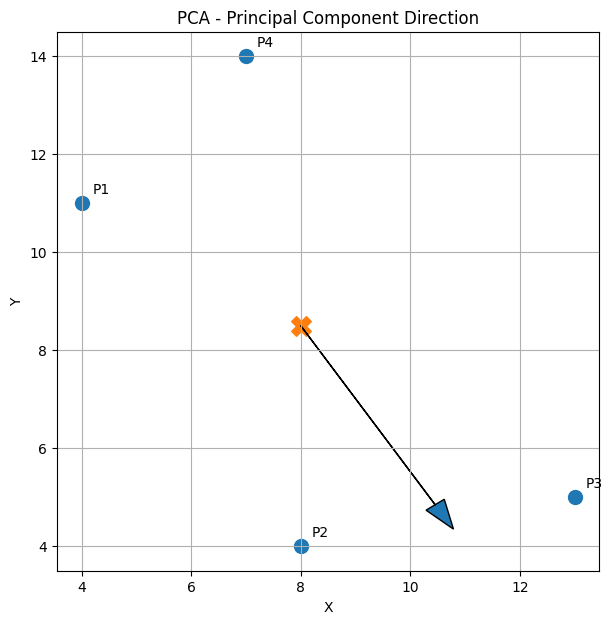


Final PCA Result:

   Original X  Original Y  Reduced to 1D (PC1)
0           4          11            -4.305187
1           8           4             3.736129
2          13           5             5.692828
3           7          14            -5.123769


In [ ]:
# PRINCIPAL COMPONENT ANALYSIS (PCA)
# Dataset:
# (4,11), (8,4), (13,5), (7,14)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
X = np.array([[4, 11],[8, 4],[13, 5],[7, 14]])
print("Original Dataset:\n")
print(X)
mean = np.mean(X, axis=0)
print("\nMean of X and Y:")
print(mean)

X_centered = X - mean

print("\nCentered Data:")
print(X_centered)


cov_matrix = np.cov(X_centered.T)

print("\nCovariance Matrix:")
print(cov_matrix)

# --------------------------------------------------
# STEP 5: COMPUTE EIGENVALUES AND EIGENVECTORS
# --------------------------------------------------

eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

print("\nEigenvalues:")
print(eigenvalues)

print("\nEigenvectors:")
print(eigenvectors)

# --------------------------------------------------
# STEP 6: SORT EIGENVALUES IN DESCENDING ORDER
# --------------------------------------------------

sorted_index = np.argsort(eigenvalues)[::-1]

sorted_eigenvalues = eigenvalues[sorted_index]
sorted_eigenvectors = eigenvectors[:, sorted_index]

print("\nSorted Eigenvalues:")
print(sorted_eigenvalues)

print("\nSorted Eigenvectors:")
print(sorted_eigenvectors)

# --------------------------------------------------
# STEP 7: SELECT THE FIRST PRINCIPAL COMPONENT
# --------------------------------------------------

pc1 = sorted_eigenvectors[:, 0]

print("\nFirst Principal Component (PC1):")
print(pc1)

# --------------------------------------------------
# STEP 8: PROJECT DATA ONTO PC1
# --------------------------------------------------

X_reduced = np.dot(X_centered, pc1)

print("\nReduced 1D Data:")
print(X_reduced)

# --------------------------------------------------
# STEP 9: USING SKLEARN PCA
# --------------------------------------------------

pca = PCA(n_components=1)

X_pca = pca.fit_transform(X)

print("\nReduced Data using sklearn PCA:")
print(X_pca)

print("\nExplained Variance Ratio:")
print(pca.explained_variance_ratio_)

# --------------------------------------------------
# STEP 10: VISUALIZATION
# --------------------------------------------------

plt.figure(figsize=(7,7))

# Original points
plt.scatter(X[:,0], X[:,1], s=100)

for i, point in enumerate(X):
    plt.text(point[0]+0.2, point[1]+0.2, f"P{i+1}")

# Mean point
plt.scatter(mean[0], mean[1], s=200, marker='X')

# Draw principal component vector
scale = 5

plt.arrow(
    mean[0],
    mean[1],
    pc1[0]*scale,
    pc1[1]*scale,
    head_width=0.4,
    length_includes_head=True
)

plt.xlabel("X")
plt.ylabel("Y")
plt.title("PCA - Principal Component Direction")
plt.grid(True)

plt.show()

# --------------------------------------------------
# STEP 11: FINAL RESULT TABLE
# --------------------------------------------------

result = pd.DataFrame({
    "Original X": X[:,0],
    "Original Y": X[:,1],
    "Reduced to 1D (PC1)": X_reduced
})

print("\nFinal PCA Result:\n")
print(result)